🔹 What is Parallelization?

Definition: Parallelization means running multiple tasks at the same time instead of sequentially.

In LangGraph, you can design a workflow where multiple nodes branch out in parallel from one step.

Once all are done, results can be combined downstream.

🔹 Analogy

Imagine you’re cooking dinner 🍽️:

One person boils pasta.

Another chops vegetables.

Another grills chicken.

All tasks happen at the same time → dinner is ready faster.

If you did them sequentially, it would take much longer.

🔹 Simple LangGraph Example (Parallel Nodes)

Here’s a workflow where:

User asks a question.

We run two parallel tasks:

Generate a short answer

Generate a detailed explanation

Combine results into a final response.

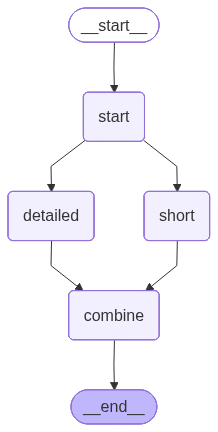

In [2]:
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv
from IPython.display import Image, display
load_dotenv()

import os

# 1. Define state
class State(TypedDict):
    query: str
    short: str
    detailed: str
    combined: str

# 2. LLM
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")

# 3. Node: Start (fan-out to parallel tasks)
def start_node(state: State):
    return {}  # nothing to add, just trigger next steps

# 4. Parallel node: Short answer
def short_answer(state: State):
    resp = llm.invoke(f"Answer briefly: {state['query']}")
    return {"short": resp.content}

# 5. Parallel node: Detailed answer
def detailed_answer(state: State):
    resp = llm.invoke(f"Explain in detail: {state['query']}")
    return {"detailed": resp.content}

# 6. Combine results
def combine(state: State):
    return {
        "combined": f"Short Answer:\n{state.get('short','')}\
\n\nDetailed Answer:\n{state.get('detailed','')}"
    }

# 7. Build graph
workflow = StateGraph(State)

workflow.add_node("start", start_node)
workflow.add_node("short", short_answer)
workflow.add_node("detailed", detailed_answer)
workflow.add_node("combine", combine)

workflow.set_entry_point("start")

# Parallel fan-out from "start"
workflow.add_edge("start", "short")
workflow.add_edge("start", "detailed")

# Both feed into combine
workflow.add_edge("short", "combine")
workflow.add_edge("detailed", "combine")
workflow.add_edge("combine", END)

# 8. Compile
app = workflow.compile()

# View
display(Image(app.get_graph().draw_mermaid_png()))


In [3]:
# 9. Run
result = app.invoke({"query": "What is machine learning?"})

print("\n✅ Final Combined Answer:\n", result["combined"])


✅ Final Combined Answer:
 Short Answer:
<think>
Okay, I need to explain machine learning briefly. Let me start by recalling what I know. Machine learning is a subset of artificial intelligence, right? It's about systems that learn from data. But how do I put that concisely?

Hmm, maybe start with the basic idea: machines learning without being explicitly programmed. I remember that instead of following strict rules, they use algorithms to learn patterns from data. So examples like recognizing images or predicting trends come to mind.

Wait, there are different types like supervised, unsupervised, and reinforcement learning. Should I mention those? The user asked for a brief answer, so maybe just mention that it involves algorithms improving with experience.

Also, applications are important. Things like recommendation systems, speech recognition, self-driving cars. But again, the answer should be short. So maybe just list a couple of applications as examples.

Let me check if I'm miss